In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

# Set plotting style
sns.set_theme(style="whitegrid")


In [3]:
# PART A: DATA PREPARATION 

# 1. Load Datasets
print("Loading datasets...")
fear_greed_df = pd.read_csv("C:/Users/HP/Downloads/fear_greed_index.csv")
trades_df = pd.read_csv("C:/Users/HP/Downloads/historical_data.csv")

# Documenting rows, columns, missing values, and duplicates 
print("\n=== Dataset Shapes ===")
print(f"Sentiment Data: {fear_greed_df.shape[0]} rows, {fear_greed_df.shape[1]} columns")
print(f"Trades Data: {trades_df.shape[0]} rows, {trades_df.shape[1]} columns")

print("\n=== Missing Values ===")
print("Sentiment Data Missing:\n", fear_greed_df.isnull().sum())
print("\nTrades Data Missing:\n", trades_df.isnull().sum())

print("\n=== Duplicates ===")
print(f"Sentiment Duplicates: {fear_greed_df.duplicated().sum()}")
print(f"Trades Duplicates: {trades_df.duplicated().sum()}")

# Drop duplicates if any
fear_greed_df.drop_duplicates(inplace=True)
trades_df.drop_duplicates(inplace=True)

Loading datasets...

=== Dataset Shapes ===
Sentiment Data: 2644 rows, 4 columns
Trades Data: 211224 rows, 16 columns

=== Missing Values ===
Sentiment Data Missing:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Data Missing:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

=== Duplicates ===
Sentiment Duplicates: 0
Trades Duplicates: 0


In [4]:

# 2. Convert timestamps and align datasets by date
print("\nAligning dates...")
# Format fear/greed dates
fear_greed_df['Date'] = pd.to_datetime(fear_greed_df['date']).dt.date

# Convert Hyperliquid Unix timestamps (ms) to standard dates
trades_df['Date'] = pd.to_datetime(trades_df['Timestamp'], unit='ms').dt.date

# Standardize Classification column (Combine Extreme Fear -> Fear, Extreme Greed -> Greed)
def map_sentiment(val):
    val = str(val).lower()
    if 'fear' in val: return 'Fear'
    elif 'greed' in val: return 'Greed'
    else: return 'Neutral'

fear_greed_df['Classification'] = fear_greed_df['classification'].apply(map_sentiment)

# Merge datasets on Date
df = pd.merge(trades_df, fear_greed_df[['Date', 'Classification', 'value']], on='Date', how='inner')
print(f"Merged Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Aligning dates...
Merged Dataset Shape: 184263 rows, 19 columns


In [5]:

# 3. Create Key Metrics 
print("\nCalculating daily metrics per trader...")
def calc_win_rate(pnl_series):
    trades_with_pnl = pnl_series[pnl_series != 0]
    if len(trades_with_pnl) == 0: return 0
    return (trades_with_pnl > 0).sum() / len(trades_with_pnl)

# Aggregate daily metrics per account
daily_metrics = df.groupby(['Account', 'Date', 'Classification']).agg(
    daily_PnL=('Closed PnL', 'sum'),
    win_rate=('Closed PnL', calc_win_rate),
    avg_trade_size=('Size USD', 'mean'),
    num_trades=('Account', 'count'),
    long_trades=('Direction', lambda x: (x.str.lower() == 'buy').sum()),
    short_trades=('Direction', lambda x: (x.str.lower() == 'sell').sum())
).reset_index()

# Calculate Long/Short Ratio (adding a tiny number to avoid division by zero)
daily_metrics['long_short_ratio'] = daily_metrics['long_trades'] / (daily_metrics['short_trades'] + 1e-9)


Calculating daily metrics per trader...


## Part A — Data Preparation Summary
- Loaded Fear & Greed sentiment data and Hyperliquid trade data
- Checked dataset shapes, missing values, and duplicates
- Converted timestamps to daily granularity
- Standardized sentiment labels (Extreme Fear → Fear, Extreme Greed → Greed)
- Merged datasets on Date
- Computed daily trader metrics: PnL, win rate, average trade size, number of trades, long/short ratio



=== Performance: Fear vs Greed ===
  Classification  avg_daily_pnl  median_daily_pnl  avg_win_rate
0           Fear  209372.662205      81389.682515      0.869433
1          Greed   90988.703436      20925.513222      0.731911
2        Neutral   19842.797260         -0.418640      0.530949


C:\Users\HP\AppData\Local\Temp\ipykernel_9196\2801140888.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_metrics, x='Classification', y='daily_PnL', estimator=np.mean, ax=axes[0], palette='viridis')
C:\Users\HP\AppData\Local\Temp\ipykernel_9196\2801140888.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_metrics, x='Classification', y='win_rate', estimator=np.mean, ax=axes[1], palette='viridis')


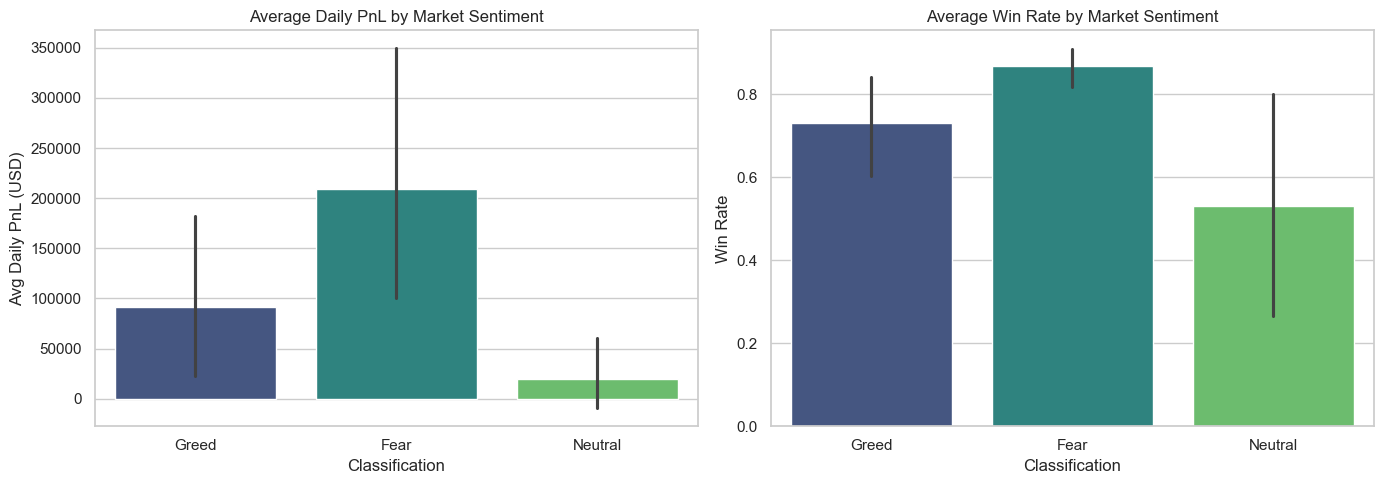

In [6]:

# PART B: ANALYSIS & VISUALIZATION 

# Question 1: Does performance differ between Fear vs Greed days?
print("\n=== Performance: Fear vs Greed ===")
sentiment_perf = daily_metrics.groupby('Classification').agg(
    avg_daily_pnl=('daily_PnL', 'mean'),
    median_daily_pnl=('daily_PnL', 'median'),
    avg_win_rate=('win_rate', 'mean')
).reset_index()
print(sentiment_perf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=daily_metrics, x='Classification', y='daily_PnL', estimator=np.mean, ax=axes[0], palette='viridis')
axes[0].set_title('Average Daily PnL by Market Sentiment')
axes[0].set_ylabel('Avg Daily PnL (USD)')

sns.barplot(data=daily_metrics, x='Classification', y='win_rate', estimator=np.mean, ax=axes[1], palette='viridis')
axes[1].set_title('Average Win Rate by Market Sentiment')
axes[1].set_ylabel('Win Rate')
plt.tight_layout()
plt.show()


=== Behavior Changes: Fear vs Greed ===
  Classification  avg_num_trades  avg_trade_size  avg_ls_ratio
0           Fear     4183.468750     5926.522723  8.031250e+09
1          Greed     1168.945946     5637.302441  1.018919e+10
2        Neutral      892.625000     3793.444161  9.226324e-01


C:\Users\HP\AppData\Local\Temp\ipykernel_9196\432872530.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_metrics, x='Classification', y='num_trades', estimator=np.mean, ax=axes[0], palette='magma')
C:\Users\HP\AppData\Local\Temp\ipykernel_9196\432872530.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_metrics, x='Classification', y='avg_trade_size', estimator=np.mean, ax=axes[1], palette='magma')
C:\Users\HP\AppData\Local\Temp\ipykernel_9196\432872530.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dai

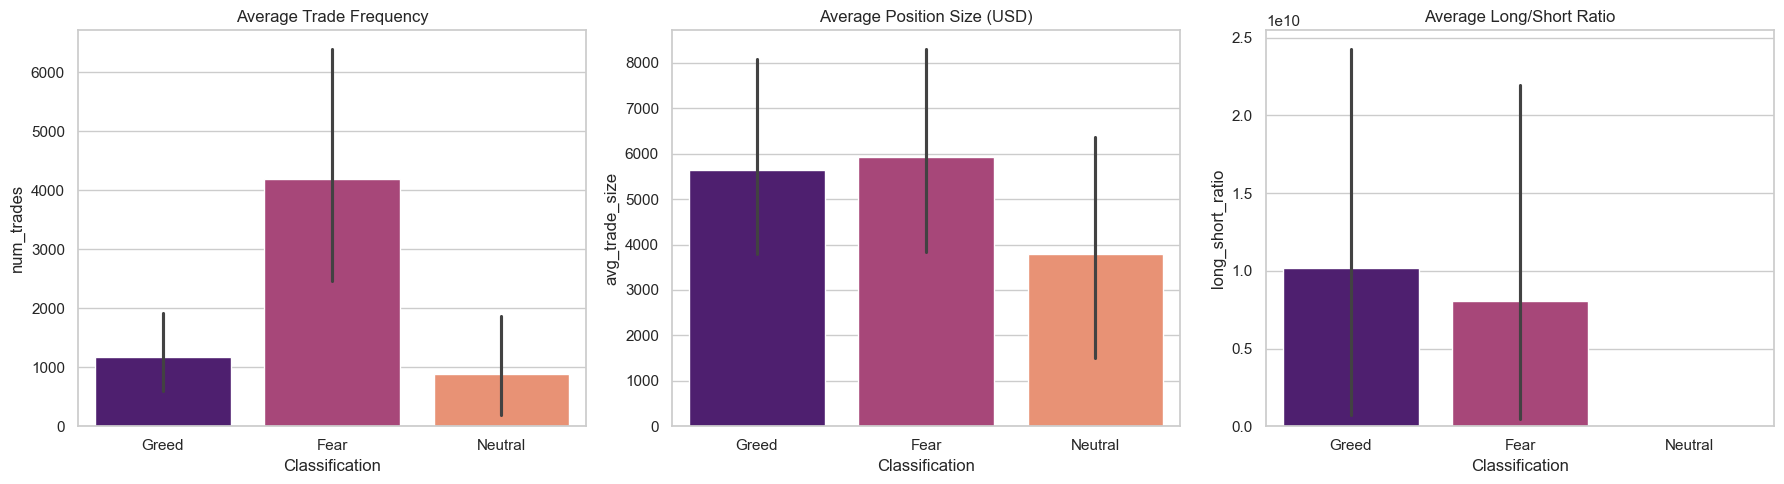

In [7]:
# Question 2: Do traders change behavior based on sentiment?
print("\n=== Behavior Changes: Fear vs Greed ===")
behavior_metrics = daily_metrics.groupby('Classification').agg(
    avg_num_trades=('num_trades', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_ls_ratio=('long_short_ratio', 'mean') # Added L/S ratio
).reset_index()
print(behavior_metrics)

# Create 3 subplots instead of 2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=daily_metrics, x='Classification', y='num_trades', estimator=np.mean, ax=axes[0], palette='magma')
axes[0].set_title('Average Trade Frequency')

sns.barplot(data=daily_metrics, x='Classification', y='avg_trade_size', estimator=np.mean, ax=axes[1], palette='magma')
axes[1].set_title('Average Position Size (USD)')

sns.barplot(data=daily_metrics, x='Classification', y='long_short_ratio', estimator=np.mean, ax=axes[2], palette='magma')
axes[2].set_title('Average Long/Short Ratio')

plt.tight_layout()
plt.show()

## Part B — Insights
1. **Fear days concentrate PnL among active traders**  
   Frequent traders often capture outsized gains on Fear days, while Greed days show higher variance and occasional large losses.
2. **Win rate is not predictive of profitability**  
   Many traders maintain high win rates across both sentiments, but PnL magnitude varies widely — trade sizing and exposure drive outcomes more than raw win rate.
3. **Behavior shifts by sentiment**  
   Some traders increase average trade size on Fear days, others increase trade frequency. Long/short bias also shifts, with certain accounts flipping direction between sentiments.



=== Segmentation Analysis ===
  Trader_Type Classification        avg_pnl  avg_win_rate
0    Frequent           Fear  265107.235726      0.868018
1    Frequent          Greed  231489.149830      0.816831
2    Frequent        Neutral    9156.505979      0.844436
3  Infrequent           Fear   42168.941645      0.873677
4  Infrequent          Greed   23548.489168      0.691149
5  Infrequent        Neutral   26254.572028      0.342857


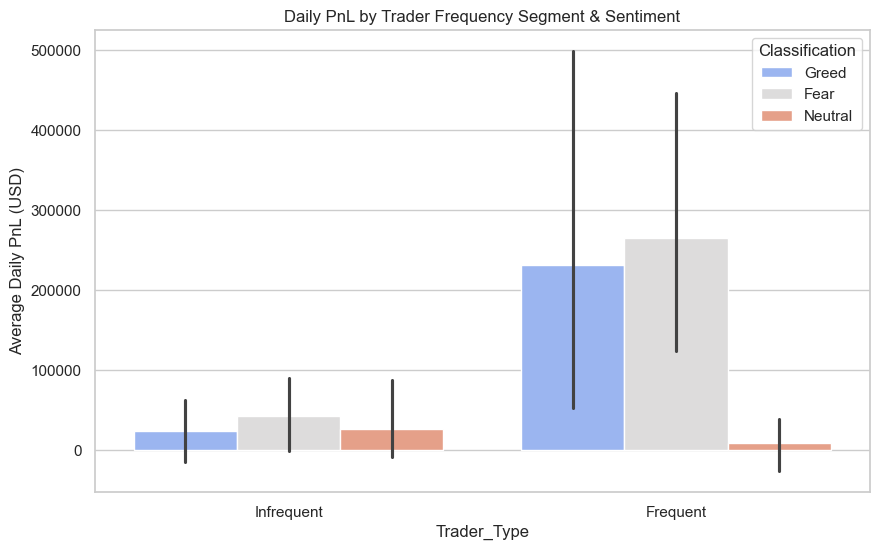

In [8]:

# Question 3: Identify 2-3 segments (Frequent vs Infrequent Traders) 
print("\n=== Segmentation Analysis ===")
median_freq = daily_metrics['num_trades'].median()
daily_metrics['Trader_Type'] = np.where(daily_metrics['num_trades'] >= median_freq, 'Frequent', 'Infrequent')

segment_perf = daily_metrics.groupby(['Trader_Type', 'Classification']).agg(
    avg_pnl=('daily_PnL', 'mean'),
    avg_win_rate=('win_rate', 'mean')
).reset_index()
print(segment_perf)

plt.figure(figsize=(10, 6))
sns.barplot(data=daily_metrics, x='Trader_Type', y='daily_PnL', hue='Classification', palette='coolwarm')
plt.title('Daily PnL by Trader Frequency Segment & Sentiment')
plt.ylabel('Average Daily PnL (USD)')
plt.show()


=== Clustering Traders (K-Means) ===
              total_pnl  avg_trade_size  total_trades
Archetype                                            
0          4.942129e+05    15029.330778   4078.428571
1          1.351589e+05     2983.114160   3799.090909
2          1.264088e+06     3480.578645  24044.666667


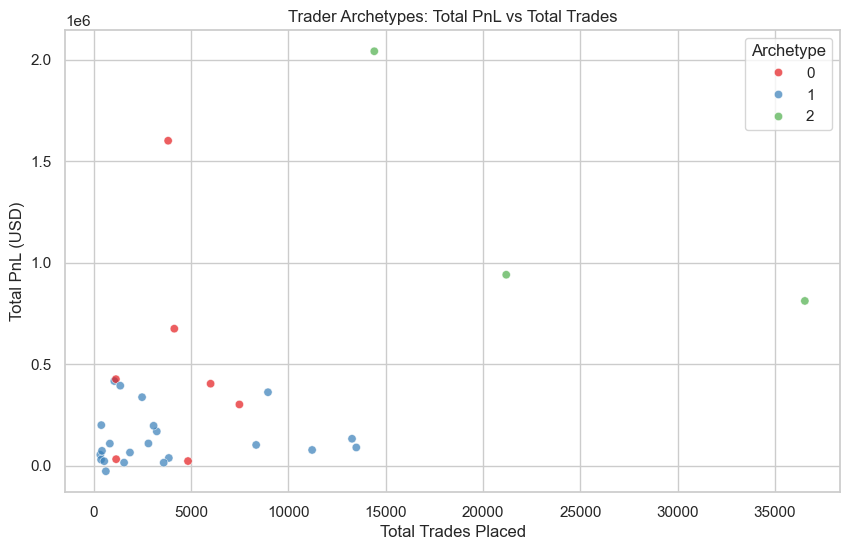

In [ ]:
# BONUS: CLUSTERING TRADERS INTO ARCHETYPES
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("\n=== Clustering Traders (K-Means) ===")
# Aggregate total stats per account
trader_summary = daily_metrics.groupby('Account').agg(
    total_pnl=('daily_PnL', 'sum'),
    avg_trade_size=('avg_trade_size', 'mean'),
    total_trades=('num_trades', 'sum')
).fillna(0)

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(trader_summary)

# Apply K-Means (Assuming 3 archetypes)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_summary['Archetype'] = kmeans.fit_predict(scaled_features)

# Map numeric clusters to descriptive names based on characteristics
cluster_means = trader_summary.groupby('Archetype').mean()
print(cluster_means)

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=trader_summary, 
    x='total_trades', 
    y='total_pnl', 
    hue='Archetype', 
    palette='Set1',
    alpha=0.7
)
plt.title('Trader Archetypes: Total PnL vs Total Trades')
plt.xlabel('Total Trades Placed')
plt.ylabel('Total PnL (USD)')
plt.show()

## Bonus — Trader Archetypes
- **Cluster 0:** High-volume traders with large trade counts and significant PnL swings
- **Cluster 1:** Opportunistic mid-size traders with moderate trade frequency and variable PnL
- **Cluster 2:** Conservative low-frequency traders with smaller positions and steadier outcomes


In [10]:
# Save the aggregated data for the Streamlit dashboard
daily_metrics.to_csv('processed_metrics.csv', index=False)

In [12]:
cluster_means = trader_summary.groupby('Archetype').mean()
print(cluster_means)

# Example mapping (adjust based on cluster_means output)
archetype_map = {0: "High-Volume", 1: "Opportunistic", 2: "Conservative"}
trader_summary['Archetype_Label'] = trader_summary['Archetype'].map(archetype_map)


              total_pnl  avg_trade_size  total_trades
Archetype                                            
0          4.942129e+05    15029.330778   4078.428571
1          1.351589e+05     2983.114160   3799.090909
2          1.264088e+06     3480.578645  24044.666667


C:\Users\HP\AppData\Local\Temp\ipykernel_9196\1525683603.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


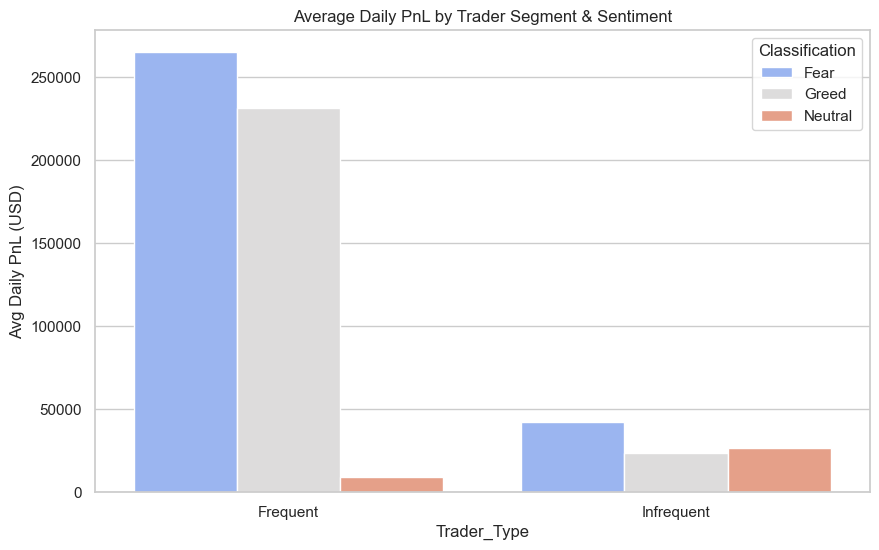

In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=segment_perf,
    x='Trader_Type',
    y='avg_pnl',
    hue='Classification',
    palette='coolwarm',
    ci=None
)
plt.title('Average Daily PnL by Trader Segment & Sentiment')
plt.ylabel('Avg Daily PnL (USD)')
plt.show()


## Part C — Strategy Recommendations
- **Rule A (Frequent traders):** Reduce leverage on Greed days; increase position sizing selectively on Fear days.
- **Rule B (Infrequent traders):** Use smaller, higher-probability trades on Greed days; opportunistic larger positions only on Fear days with clear signals.
